<a href="https://colab.research.google.com/github/Ananya1812-iilm/Ananya_Pradhan_25SCS1003000489_IILM_GN/blob/main/E_COMMERCE_data__cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

In [39]:
from google.colab import files

uploaded = files.upload()

filename = next(iter(uploaded))

df = pd.read_csv(filename)

print("Dataset Loaded Successfully")
print(df.head())

Saving E-commercedataset.csv to E-commercedataset (1).csv
Dataset Loaded Successfully
   Unnamed: 0                                               Name  \
0           0          Apple MacBook Air 13 M1 MGN63 (8GB-256GB)   
1           1                 Apple Macbook Air 13 MW123 M4 Chip   
2           2  ASUS Zenbook 14 UX3405CA Intel Core Ultra 7 25...   
3           3  Lenovo ThinkPad E16 Gen 2 - Intel Core Ultra 7...   
4           4          Lenovo IdeaPad Slim 3 Ryzen 7 (8GB-512GB)   

   Discounted Price  Actual Price   Saving  Rating  Reviews   Brand     Core  \
0            203499      258000.0  21% OFF     5.0      2.0   Apple       M1   
1            281999      350000.0  19% OFF     4.3      5.0   Apple       M4   
2            285999      330000.0  13% OFF     NaN      NaN    ASUS  Ultra 7   
3            287999      340000.0  15% OFF     NaN      NaN  Lenovo  Ultra 7   
4            146999      175000.0  16% OFF     NaN      NaN  Lenovo  Ryzen 7   

              SSD       

In [40]:
print(df.info())

print(df.shape)

print(df.columns)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 306 entries, 0 to 305
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        306 non-null    int64  
 1   Name              306 non-null    object 
 2   Discounted Price  306 non-null    int64  
 3   Actual Price      291 non-null    float64
 4   Saving            291 non-null    object 
 5   Rating            26 non-null     float64
 6   Reviews           26 non-null     float64
 7   Brand             306 non-null    object 
 8   Core              219 non-null    object 
 9   SSD               92 non-null     object 
 10  Model             306 non-null    object 
dtypes: float64(3), int64(2), object(6)
memory usage: 26.4+ KB
None
(306, 11)
Index(['Unnamed: 0', 'Name', 'Discounted Price', 'Actual Price', 'Saving',
       'Rating', 'Reviews', 'Brand', 'Core', 'SSD', 'Model'],
      dtype='object')


In [41]:
if "Unnamed: 0" in df.columns:
    df.drop("Unnamed: 0", axis=1, inplace=True)

In [42]:
print("\nMissing Values")
print(df.isnull().sum())

# Fill categorical values

for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].fillna(df[col].mode()[0])


Missing Values
Name                  0
Discounted Price      0
Actual Price         15
Saving               15
Rating              280
Reviews             280
Brand                 0
Core                 87
SSD                 214
Model                 0
dtype: int64


In [43]:
price_columns = [
    "Discounted Price",
    "Actual Price",
    "Saving"
]

for col in price_columns:

    df[col] = (
        df[col]
        .astype(str)
        .str.replace("₹","",regex=False)
        .str.replace(",","",regex=False)
        .str.replace("%","",regex=False)
        .str.strip()
    )

    df[col] = pd.to_numeric(df[col], errors="coerce")

In [44]:
df["Rating"] = pd.to_numeric(df["Rating"], errors="coerce")

In [45]:
df["Reviews"] = (
    df["Reviews"]
    .astype(str)
    .str.replace(",","",regex=False)
)

df["Reviews"] = pd.to_numeric(df["Reviews"], errors="coerce")


In [46]:
numeric = df.select_dtypes(include=np.number).columns

for col in numeric:
    df[col] = df[col].fillna(df[col].median())


In [47]:
print("Duplicate Rows :",df.duplicated().sum())

df.drop_duplicates(inplace=True)

print("Shape :",df.shape)

Duplicate Rows : 0
Shape : (306, 10)


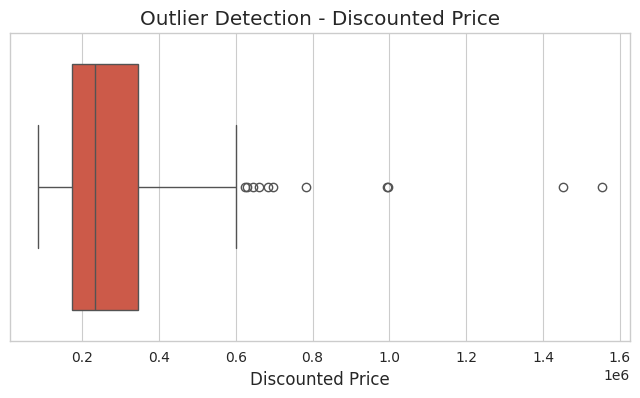

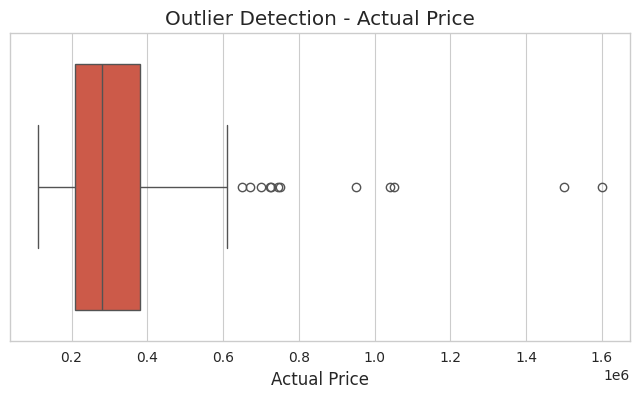

Skipping Saving (No data)


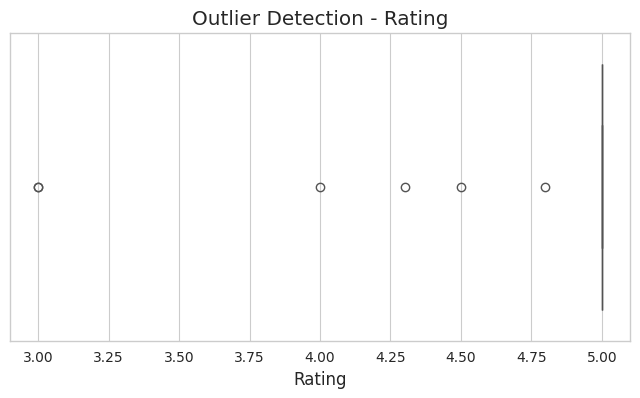

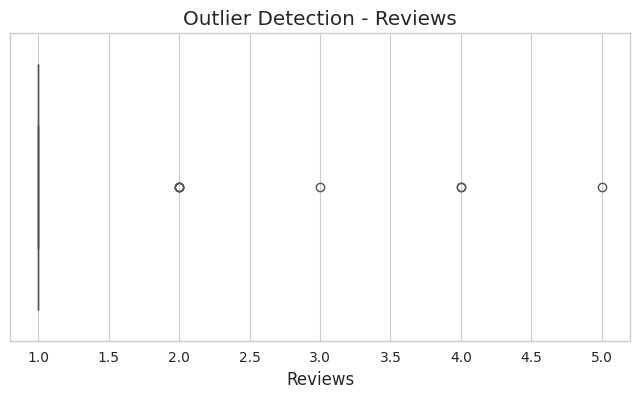

In [49]:
numeric_cols = ['Discounted Price', 'Actual Price', 'Saving', 'Rating', 'Reviews']

for col in numeric_cols:

    if col in df.columns:


        temp = df[col].dropna()


        if len(temp) == 0:
            print(f"Skipping {col} (No data)")
            continue

        plt.figure(figsize=(8,4))

        sns.boxplot(x=temp)

        plt.title(f"Outlier Detection - {col}")

        plt.xlabel(col)

        plt.show()

In [50]:
print(df.describe())

       Discounted Price  Actual Price  Saving      Rating     Reviews
count      3.060000e+02  3.060000e+02     0.0  306.000000  306.000000
mean       2.775879e+05  3.192390e+05     NaN    4.979085    1.052288
std        1.708020e+05  1.759977e+05     NaN    0.177839    0.367372
min        8.599900e+04  1.119990e+05     NaN    3.000000    1.000000
25%        1.742490e+05  2.099992e+05     NaN    5.000000    1.000000
50%        2.344990e+05  2.800000e+05     NaN    5.000000    1.000000
75%        3.449998e+05  3.799998e+05     NaN    5.000000    1.000000
max        1.552999e+06  1.599900e+06     NaN    5.000000    5.000000


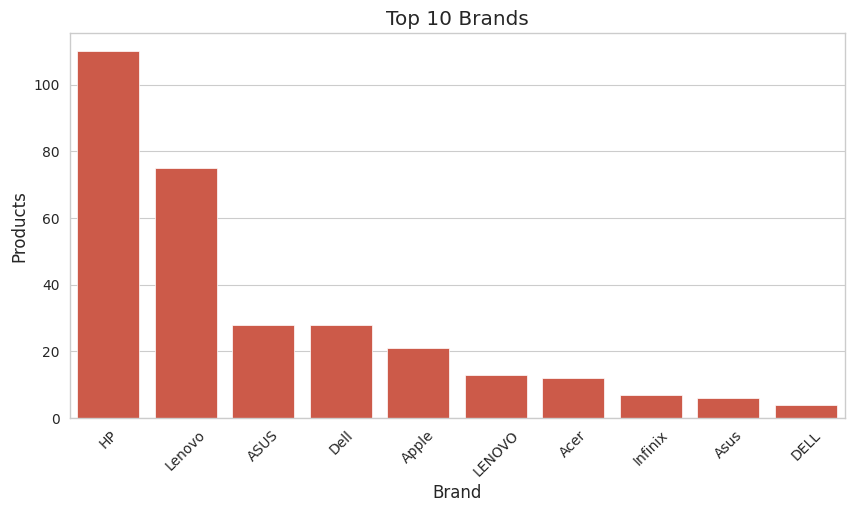

In [51]:
plt.figure(figsize=(10,5))

top_brand = df["Brand"].value_counts().head(10)

sns.barplot(
    x=top_brand.index,
    y=top_brand.values
)

plt.xticks(rotation=45)

plt.title("Top 10 Brands")

plt.xlabel("Brand")

plt.ylabel("Products")

plt.show()

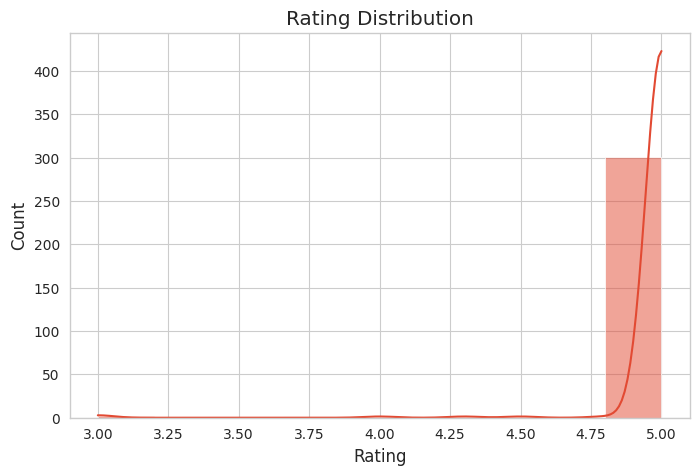

In [52]:
plt.figure(figsize=(8,5))

sns.histplot(df["Rating"], bins=10, kde=True)

plt.title("Rating Distribution")

plt.show()

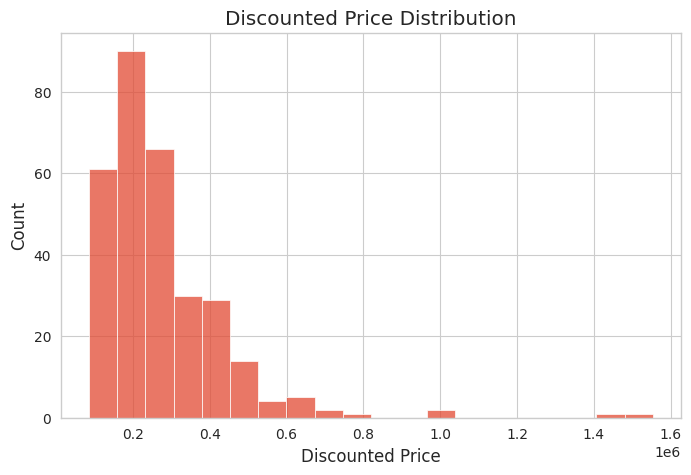

In [53]:
plt.figure(figsize=(8,5))

sns.histplot(df["Discounted Price"], bins=20)

plt.title("Discounted Price Distribution")

plt.show()

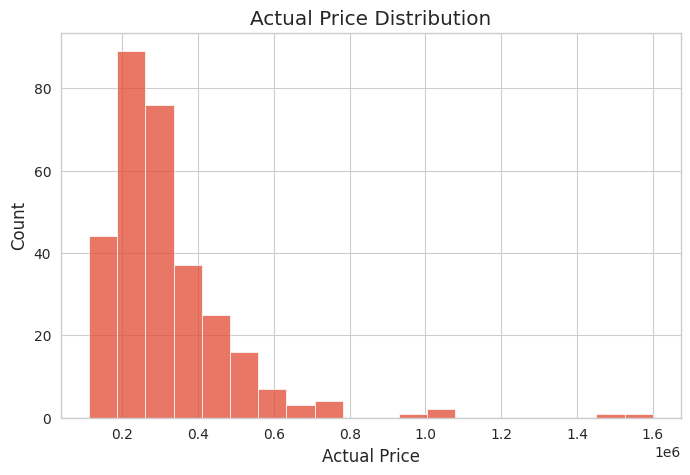

In [54]:
plt.figure(figsize=(8,5))

sns.histplot(df["Actual Price"], bins=20)

plt.title("Actual Price Distribution")

plt.show()

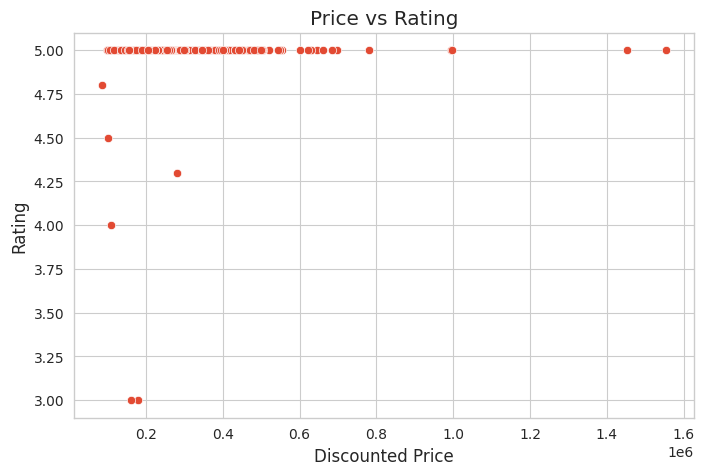

In [55]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Discounted Price",
    y="Rating"
)

plt.title("Price vs Rating")

plt.show()

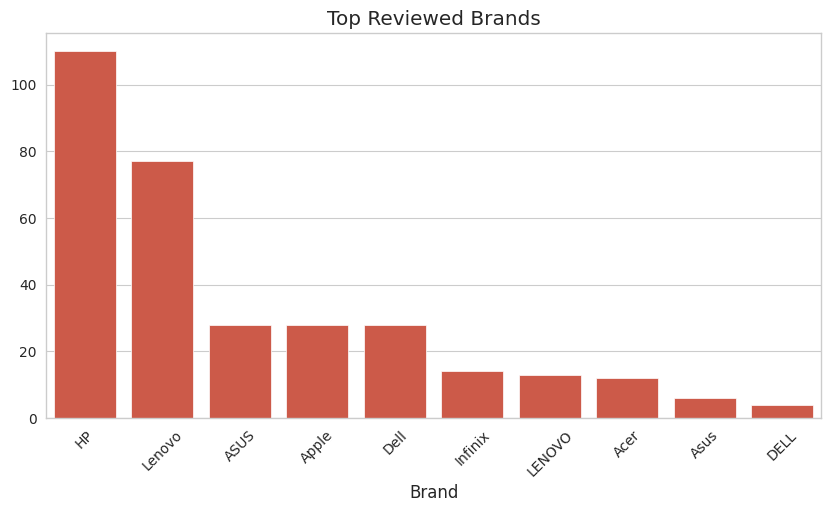

In [56]:
top = (
    df.groupby("Brand")["Reviews"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))

sns.barplot(
    x=top.index,
    y=top.values
)

plt.xticks(rotation=45)

plt.title("Top Reviewed Brands")

plt.show()

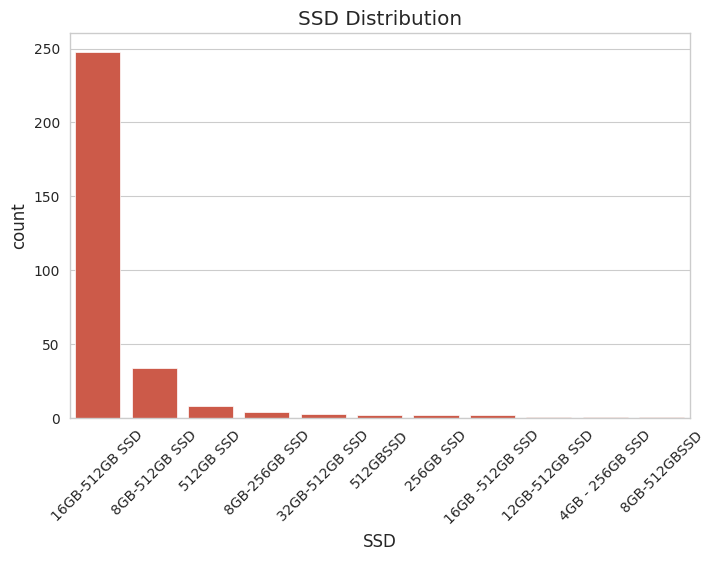

In [58]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="SSD",
    order=df["SSD"].value_counts().index
)

plt.xticks(rotation=45)

plt.title("SSD Distribution")

plt.show()

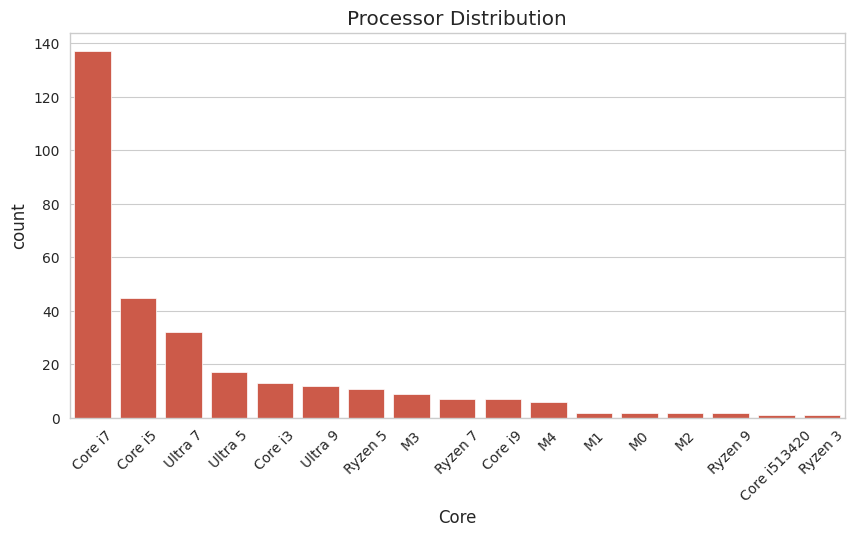

In [59]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="Core",
    order=df["Core"].value_counts().index
)

plt.xticks(rotation=45)

plt.title("Processor Distribution")

plt.show()

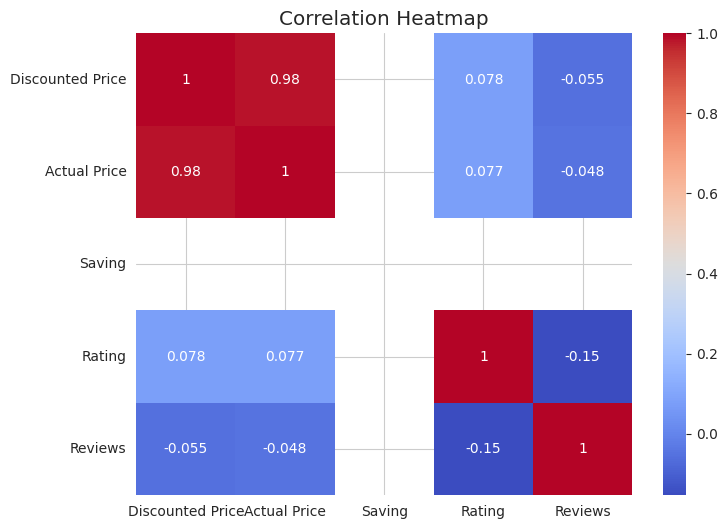

In [60]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

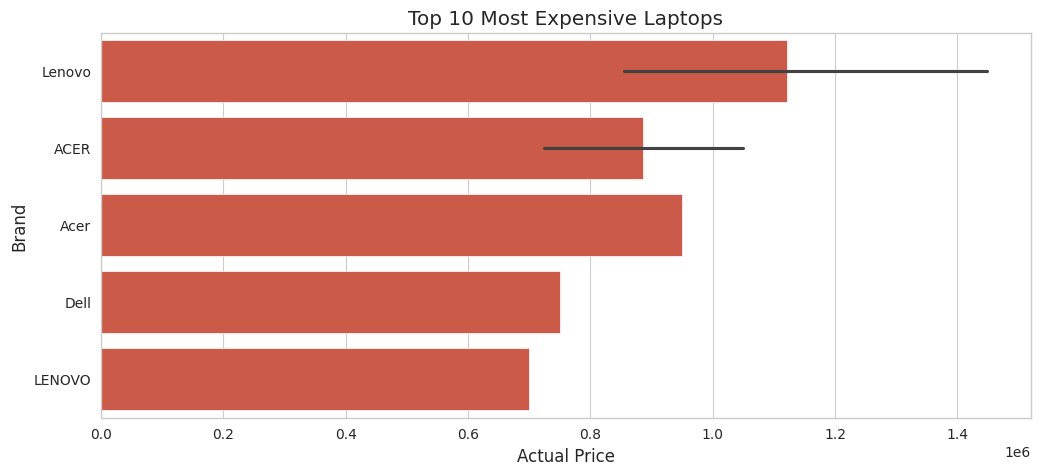

In [61]:
expensive = df.nlargest(10,"Actual Price")

plt.figure(figsize=(12,5))

sns.barplot(
    x="Actual Price",
    y="Brand",
    data=expensive
)

plt.title("Top 10 Most Expensive Laptops")

plt.show()

In [62]:
df.to_csv("Cleaned_Ecommerce_Dataset.csv", index=False)

print("Cleaned Dataset Saved Successfully")


Cleaned Dataset Saved Successfully


In [64]:
print("\nKEY INSIGHTS")

print("\nTotal Products :",len(df))

print("\nTotal Brands :",df["Brand"].nunique())

print("\nAverage Rating :",round(df["Rating"].mean(),2))

print("\nAverage Discounted Price :",round(df["Discounted Price"].mean(),2))

print("\nHighest Rated Brands")

print(df.groupby("Brand")["Rating"].mean().sort_values(ascending=False).head())

print("\nTop Selling Brands")

print(df["Brand"].value_counts().head(10))


KEY INSIGHTS

Total Products : 306

Total Brands : 11

Average Rating : 4.98

Average Discounted Price : 277587.89

Highest Rated Brands
Brand
ACER    5.0
ASUS    5.0
Acer    5.0
Asus    5.0
Dell    5.0
Name: Rating, dtype: float64

Top Selling Brands
Brand
HP         110
Lenovo      75
ASUS        28
Dell        28
Apple       21
LENOVO      13
Acer        12
Infinix      7
Asus         6
DELL         4
Name: count, dtype: int64


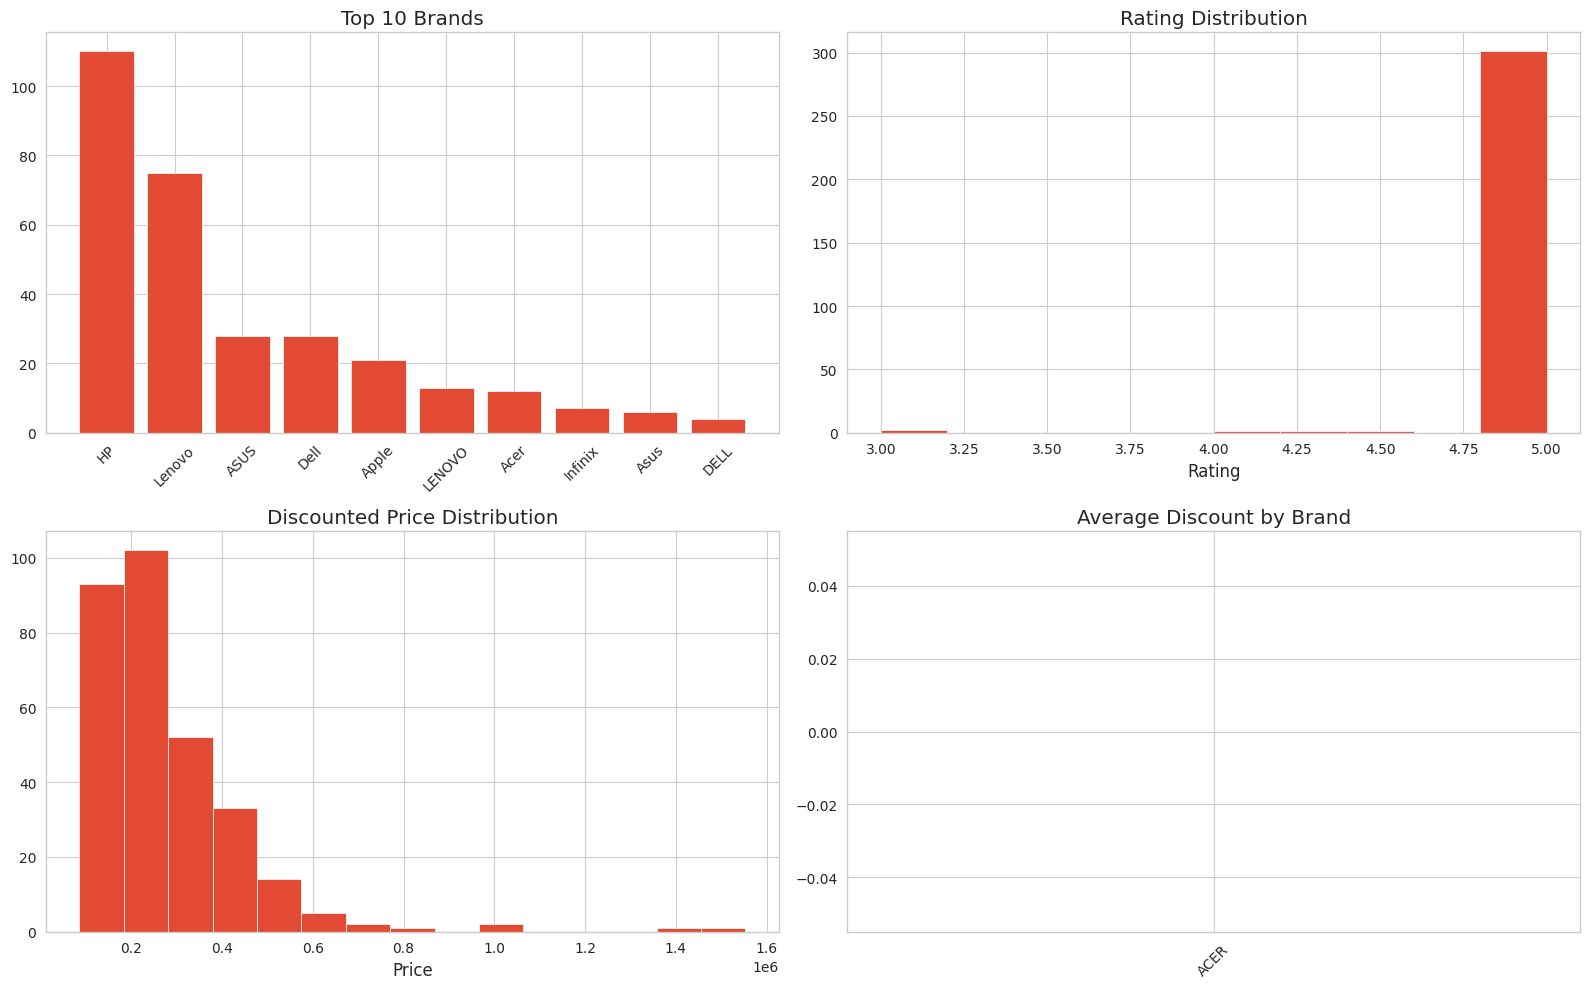

In [72]:
# DASHBOARD
fig, ax = plt.subplots(2, 2, figsize=(16, 10))

# 1. Top 10 Brands
brand_counts = df['Brand'].value_counts().head(10)

ax[0,0].bar(brand_counts.index, brand_counts.values)
ax[0,0].set_title("Top 10 Brands")
ax[0,0].tick_params(axis='x', rotation=45)

# 2. Rating Distribution
ax[0,1].hist(df['Rating'], bins=10)
ax[0,1].set_title("Rating Distribution")
ax[0,1].set_xlabel("Rating")

# 3. Discounted Price Distribution
ax[1,0].hist(df['Discounted Price'], bins=15)
ax[1,0].set_title("Discounted Price Distribution")
ax[1,0].set_xlabel("Price")

# 4. Average Discount by Brand
avg_discount = df.groupby('Brand')['Saving'].mean().sort_values(ascending=False).head(10)

ax[1,1].bar(avg_discount.index, avg_discount.values)
ax[1,1].set_title("Average Discount by Brand")
ax[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [73]:
df.to_csv("Cleaned_Ecommerce_Dataset.csv", index=False)
print("Cleaned dataset saved successfully!")
from google.colab import files
files.download("Cleaned_Ecommerce_Dataset.csv")

Cleaned dataset saved successfully!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>